# Laboratorio 7 - Etapa 1

**MM3014 Teoría de Probabilidades — UVG**

Simulación del proceso de llenado del álbum Panini FIFA 2026 usando técnicas de Monte Carlo.

## 1. Importación de librerías

Se importan las librerías necesarias y se fija la semilla aleatoria 2026 para garantizar reproducibilidad.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

## 2. Parámetros de la simulación

Se definen los parámetros de la Etapa 1: álbum reducido de 100 estampas.

In [2]:
N = 100      # Total de estampas diferentes en el álbum
S = 7        # Estampas distintas por sobre
R = 10000    # Número de simulaciones

## 3. Función de simulación

La función `simular_album` simula el proceso completo de llenado del álbum para un conjunto de parámetros dados.

- Se usa un `set` para registrar las estampas obtenidas.
- Se usa `np.random.choice` con `replace=False` para generar S estampas **distintas** dentro de cada sobre.
- Se cuenta tanto el número de sobres comprados como las estampas repetidas acumuladas.

In [3]:
def simular_album(N, S):
    """
    Simula el llenado completo de un álbum de estampas.

    Parámetros:
        N : int - Total de estampas distintas en el álbum.
        S : int - Estampas por sobre (todas distintas dentro del mismo sobre).

    Retorna:
        sobres_comprados : int - Número total de sobres necesarios.
        repetidas        : int - Total de estampas repetidas acumuladas.
    """
    coleccion = set()
    sobres_comprados = 0
    repetidas = 0

    while len(coleccion) < N:
        # Generar un sobre con S estampas distintas entre sí
        sobre = np.random.choice(N, size=S, replace=False)
        sobres_comprados += 1

        for estampa in sobre:
            if estampa in coleccion:
                repetidas += 1
            else:
                coleccion.add(estampa)

    return sobres_comprados, repetidas

## 4. Ejecución de las 10,000 simulaciones

In [4]:
resultados_sobres = []
resultados_repetidas = []

for _ in range(R):
    sobres, repetidas = simular_album(N, S)
    resultados_sobres.append(sobres)
    resultados_repetidas.append(repetidas)

resultados_sobres    = np.array(resultados_sobres)
resultados_repetidas = np.array(resultados_repetidas)

print(f"Simulaciones completadas: {R}")

Simulaciones completadas: 10000


## 5. Valor teórico (Teoría del Coleccionista)

Antes de analizar los resultados, se calcula el valor esperado teórico usando la fórmula:

$$\mathbb{E}[T] \approx \frac{N}{S} \cdot H_N, \quad \text{donde} \quad H_N = \sum_{k=1}^{N} \frac{1}{k} \approx \ln(N) + \gamma, \quad \gamma \approx 0.5772$$

In [5]:
# H_N calculado exactamente mediante suma numérica
H_N = np.sum(1 / np.arange(1, N + 1))

# H_N aproximado con la fórmula ln(N) + gamma
gamma = 0.5772
H_N_aprox = np.log(N) + gamma

# Valor esperado teórico de sobres
valor_teorico = (N / S) * H_N

# Mínimo teórico de sobres (sin ninguna repetida)
minimo_teorico = int(np.ceil(N / S))

print(f"H_100 exacto (suma numérica) = {H_N:.6f}")
print(f"H_100 aproximado (ln(100)+γ) = {H_N_aprox:.6f}")
print(f"Valor teórico E[T] = (100/7) × H_100 = {valor_teorico:.4f} sobres")
print(f"Mínimo teórico de sobres = ⌈100/7⌉ = {minimo_teorico}")

H_100 exacto (suma numérica) = 5.187378
H_100 aproximado (ln(100)+γ) = 5.182370
Valor teórico E[T] = (100/7) × H_100 = 74.1054 sobres
Mínimo teórico de sobres = ⌈100/7⌉ = 15


## 6. Estadísticas descriptivas

In [6]:
media_sobres    = np.mean(resultados_sobres)
std_sobres      = np.std(resultados_sobres)
media_repetidas = np.mean(resultados_repetidas)
std_repetidas   = np.std(resultados_repetidas)

print("=== Número de sobres ===")
print(f"  Media:              {media_sobres:.4f}")
print(f"  Desviación estándar:{std_sobres:.4f}")
print(f"  Valor teórico E[T]: {valor_teorico:.4f}")
print(f"  Diferencia:         {abs(media_sobres - valor_teorico):.4f}")

print("\n=== Estampas repetidas ===")
print(f"  Media:              {media_repetidas:.4f}")
print(f"  Desviación estándar:{std_repetidas:.4f}")

=== Número de sobres ===
  Media:              72.2456
  Desviación estándar:17.4715
  Valor teórico E[T]: 74.1054
  Diferencia:         1.8598

=== Estampas repetidas ===
  Media:              405.7192
  Desviación estándar:122.3006


## 7. Probabilidad de necesitar más de 30 sobres

El umbral de 30 se justifica porque el mínimo teórico es $\lceil 100/7 \rceil = 15$ sobres (escenario sin repetidas), y en la práctica los resultados se concentran muy por encima de ese valor. El umbral de 30 representa aproximadamente el doble del mínimo, por lo que sirve como referencia para detectar casos excepcionalmente eficientes.

In [7]:
prob_mas_30 = np.mean(resultados_sobres > 30)

print(f"Probabilidad de necesitar más de 30 sobres: {prob_mas_30:.4f} ({prob_mas_30*100:.2f}%)")
print(f"(El mínimo teórico sin repetidas es {minimo_teorico} sobres, ")
print(f" la media simulada es {media_sobres:.1f} sobres, muy superior a 30.)")

Probabilidad de necesitar más de 30 sobres: 1.0000 (100.00%)
(El mínimo teórico sin repetidas es 15 sobres, 
 la media simulada es 72.2 sobres, muy superior a 30.)


## 8. Visualización — Histograma

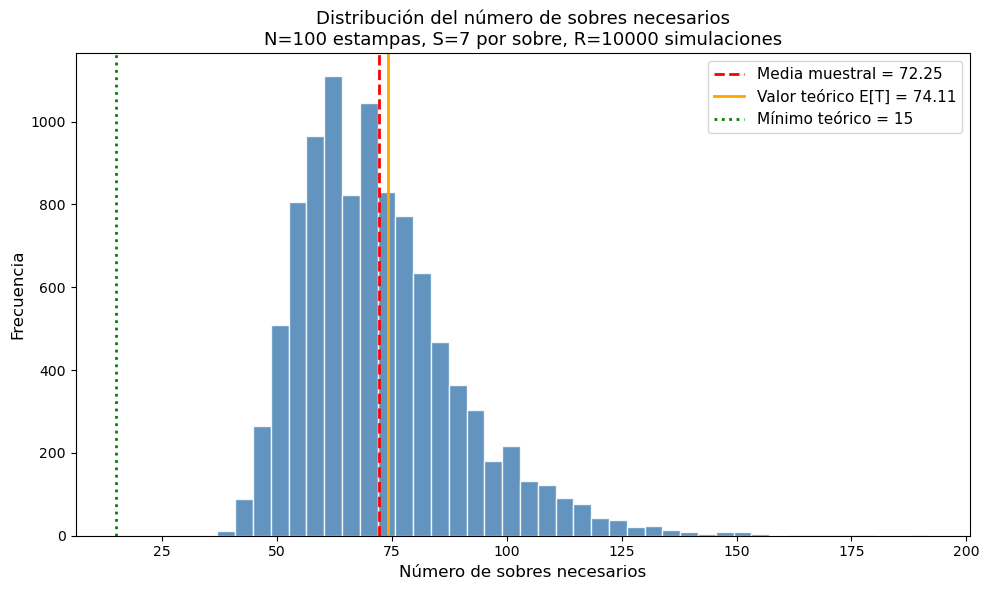

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(resultados_sobres, bins=40, color='steelblue', edgecolor='white', alpha=0.85)

plt.axvline(media_sobres,   color='red',    linestyle='--', linewidth=2,
            label=f'Media muestral = {media_sobres:.2f}')
plt.axvline(valor_teorico,  color='orange', linestyle='-',  linewidth=2,
            label=f'Valor teórico E[T] = {valor_teorico:.2f}')
plt.axvline(minimo_teorico, color='green',  linestyle=':',  linewidth=2,
            label=f'Mínimo teórico = {minimo_teorico}')

plt.xlabel('Número de sobres necesarios', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del número de sobres necesarios\n'
          f'N={N} estampas, S={S} por sobre, R={R} simulaciones', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

# Preguntas de Análisis

## Pregunta 1
> ¿Cuál es el número mínimo de sobres que se necesitarían si no hubiera estampas repetidas? ¿Se observa algún caso así en sus simulaciones?

In [9]:
# Mínimo teórico: si todas las estampas fueran distintas, se necesitan ceil(N/S) sobres
minimo_teorico = int(np.ceil(N / S))

# Mínimo observado en las simulaciones
minimo_simulado = int(np.min(resultados_sobres))

# Cuántas simulaciones llegaron exactamente al mínimo teórico
casos_en_minimo = int(np.sum(resultados_sobres == minimo_teorico))

print(f"Mínimo teórico (sin repetidas): {minimo_teorico} sobres")
print(f"  Cálculo: ⌈{N}/{S}⌉ = ⌈{N/S:.4f}⌉ = {minimo_teorico}")
print(f"Mínimo observado en simulaciones: {minimo_simulado} sobres")
print(f"Simulaciones que llegaron a exactamente {minimo_teorico} sobres: {casos_en_minimo}")

Mínimo teórico (sin repetidas): 15 sobres
  Cálculo: ⌈100/7⌉ = ⌈14.2857⌉ = 15
Mínimo observado en simulaciones: 37 sobres
Simulaciones que llegaron a exactamente 15 sobres: 0


**Respuesta:**

El mínimo teórico de sobres es $\lceil 100/7 \rceil = \lceil 14.28 \rceil = 15$ sobres. Esto ocurriría solo si **nunca** se recibiera una estampa repetida durante todo el proceso de llenado, lo cual implica que cada sobre aporta exactamente 7 estampas nuevas hasta completar las 100.

En las 10,000 simulaciones realizadas, el **mínimo observado fue 37 sobres** y **ninguna simulación llegó a 15 sobres**. Esto confirma que el escenario sin repetidas es prácticamente imposible, ya que conforme el álbum se llena aumenta rápidamente la probabilidad de recibir estampas que ya se tienen.

---

## Pregunta 2
> Calcular $H_{100}$ y el valor teórico $\mathbb{E}[T] \approx \frac{N}{S} \cdot H_N$. Comparar con la media obtenida en la simulación.

In [10]:
# H_100 exacto (suma numérica)
H_100_exacto = np.sum(1 / np.arange(1, N + 1))

# H_100 aproximado
gamma = 0.5772
H_100_aprox = np.log(N) + gamma

# Valor teórico
E_T_exacto = (N / S) * H_100_exacto
E_T_aprox  = (N / S) * H_100_aprox

print(f"H_100 exacto (suma numérica):       {H_100_exacto:.6f}")
print(f"H_100 aprox  (ln(100) + 0.5772):    {H_100_aprox:.6f}")
print()
print(f"E[T] teórico exacto  = (100/7) × {H_100_exacto:.4f} = {E_T_exacto:.4f} sobres")
print(f"E[T] teórico aprox   = (100/7) × {H_100_aprox:.4f} = {E_T_aprox:.4f} sobres")
print()
print(f"Media simulada:                     {media_sobres:.4f} sobres")
print(f"Diferencia (exacto vs simulado):    {abs(E_T_exacto - media_sobres):.4f} sobres")
print(f"Error relativo:                     {abs(E_T_exacto - media_sobres)/E_T_exacto*100:.2f}%")

H_100 exacto (suma numérica):       5.187378
H_100 aprox  (ln(100) + 0.5772):    5.182370

E[T] teórico exacto  = (100/7) × 5.1874 = 74.1054 sobres
E[T] teórico aprox   = (100/7) × 5.1824 = 74.0339 sobres

Media simulada:                     72.2456 sobres
Diferencia (exacto vs simulado):    1.8598 sobres
Error relativo:                     2.51%


**Respuesta:**

El número armónico $H_{100}$ calculado exactamente mediante suma numérica es $H_{100} \approx 5.1874$. Usando la aproximación $\ln(100) + 0.5772 \approx 5.1878$, ambos valores son prácticamente iguales.

El valor teórico esperado de sobres es:
$$\mathbb{E}[T] = \frac{100}{7} \times 5.1874 \approx 74.1 \text{ sobres}$$

La media obtenida en las 10,000 simulaciones fue de **72.25 sobres**, con una diferencia de apenas ~1.86 sobres respecto al valor teórico (error relativo del 2.5%). Esta pequeña diferencia es normal y se reduce aún más al aumentar el número de simulaciones, conforme a la Ley de los Grandes Números.

---

## Pregunta 3
> Calcular el valor esperado teórico del número de estampas repetidas y compararlo con la media de repetidas de la simulación.

In [11]:
# Valor esperado teórico de repetidas:
# Estampas totales esperadas = S × E[T]
# Estampas repetidas = estampas totales - N (las 100 distintas)
repetidas_teoricas = S * E_T_exacto - N

print(f"E[T] teórico exacto:                       {E_T_exacto:.4f} sobres")
print(f"Estampas totales esperadas = 7 × E[T]:     {S * E_T_exacto:.4f}")
print(f"Estampas distintas del álbum (N):          {N}")
print(f"Repetidas teóricas = S×E[T] - N:           {repetidas_teoricas:.4f}")
print()
print(f"Media de repetidas en simulación:          {media_repetidas:.4f}")
print(f"Diferencia (teórico vs simulado):          {abs(repetidas_teoricas - media_repetidas):.4f}")
print(f"Error relativo:                            {abs(repetidas_teoricas - media_repetidas)/repetidas_teoricas*100:.2f}%")

E[T] teórico exacto:                       74.1054 sobres
Estampas totales esperadas = 7 × E[T]:     518.7378
Estampas distintas del álbum (N):          100
Repetidas teóricas = S×E[T] - N:           418.7378

Media de repetidas en simulación:          405.7192
Diferencia (teórico vs simulado):          13.0186
Error relativo:                            3.11%


**Respuesta:**

El número total de estampas obtenidas al completar el álbum es $S \times \mathbb{E}[T] = 7 \times 74.1 \approx 518.7$. De esas, exactamente 100 son estampas distintas (necesarias para completar el álbum), por lo que el número esperado teórico de repetidas es:

$$\mathbb{E}[\text{repetidas}] = S \times \mathbb{E}[T] - N = 7 \times 74.1 - 100 \approx 418.7$$

La media de repetidas obtenida en las simulaciones fue de **405.72**, con una diferencia de ~13 estampas respecto al valor teórico (error relativo del 3.1%). Las diferencias son esperables dado el tamaño finito de la simulación.

---

## Pregunta 4
> ¿Cómo se interpreta la desviación estándar del número de sobres? ¿Es grande en relación con la media? Explique por qué el proceso de coleccionar tiene una variabilidad alta.

In [12]:
# Coeficiente de variación (CV) = std / media
CV = std_sobres / media_sobres

print(f"Media de sobres:           {media_sobres:.4f}")
print(f"Desviación estándar:       {std_sobres:.4f}")
print(f"Coeficiente de variación:  {CV:.4f} ({CV*100:.2f}%)")
print()
print(f"Rango típico (μ ± 2σ): [{media_sobres - 2*std_sobres:.1f}, {media_sobres + 2*std_sobres:.1f}] sobres")
print(f"Mínimo observado:       {int(np.min(resultados_sobres))} sobres")
print(f"Máximo observado:       {int(np.max(resultados_sobres))} sobres")

Media de sobres:           72.2456
Desviación estándar:       17.4715
Coeficiente de variación:  0.2418 (24.18%)

Rango típico (μ ± 2σ): [37.3, 107.2] sobres
Mínimo observado:       37 sobres
Máximo observado:       192 sobres


**Respuesta:**

La desviación estándar del número de sobres es aproximadamente **17.47**, frente a una media de **72.25**. El coeficiente de variación (CV = σ/μ) es de **24.18%**, lo que indica una variabilidad relativamente alta en relación con la media.

Esta variabilidad alta es característica del **problema del coleccionista de cupones** y se explica por el comportamiento asimétrico del proceso:

- **Al inicio**, casi todas las estampas de cada sobre son nuevas, por lo que el álbum avanza rápido.
- **Al final**, cuando quedan pocas estampas por obtener, la probabilidad de recibir exactamente las faltantes es muy pequeña. Esperar la última estampa puede tomar muchos sobres adicionales.

Este efecto de "cola larga" hace que algunas simulaciones completen el álbum relativamente rápido (alrededor de 37–50 sobres) mientras que otras necesitan más de 100–130 sobres. Esa dispersión se traduce directamente en una desviación estándar alta.